# Computer Exercise 13.4 — Problem 2

## 부등식 제약 이차계획(QP): 활성집합법(Active-Set Method)

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.4 Quadratic Programming & Duality — *Inequality-Constrained QP / Active-Set*
> **풀이 일자**: Day 49
> **언어**: Python 3 (NumPy / SciPy / pandas / matplotlib)

## 1. 문제 (원문)

> **2.** Implement a primal **active-set method** for the convex QP
> $$\min_{\mathbf{x}}\;\tfrac12\mathbf{x}^{\top}Q\mathbf{x}+\mathbf{c}^{\top}\mathbf{x}
> \quad\text{s.t.}\quad G\mathbf{x}\le\mathbf{h}.$$
> Apply it to
> $$\min\;(x-2)^2+(y-2)^2\quad\text{s.t.}\quad x+y\le2,\ x\ge0,\ y\ge0,$$
> starting from a feasible vertex. Report the **working set** at each iteration, the
> Lagrange multipliers, and verify against `scipy.optimize.minimize` (SLSQP).
> Visualize the feasible region, objective contours, and the iterate path to the optimum.

### 한국어 풀이용 정리
부등식 제약 QP의 핵심 난점은 **어떤 제약이 등식으로 active한지 모른다**는 것. 활성집합법은
현재 활성으로 추정한 제약집합(working set)을 **등식으로 고정**해 등식 QP(Problem 1)를 풀고,
(i) 스텝이 다른 제약을 위반하면 그 제약을 추가(blocking), (ii) 활성 제약의 승수가 음수면 그
제약을 제거 — 를 반복한다. 무제약 최소점 $(2,2)$ 는 실현불가능하므로 해는 **경계** $x+y=2$ 위에 놓인다.

## 2. 수학적 배경

### 2.1 KKT 조건 (부등식)
$\min\tfrac12\mathbf{x}^\top Q\mathbf{x}+\mathbf{c}^\top\mathbf{x}$ s.t. $G\mathbf{x}\le\mathbf{h}$ 의 최적성:
$$Q\mathbf{x}+\mathbf{c}+G^\top\boldsymbol\mu=0,\quad G\mathbf{x}\le\mathbf{h},\quad \boldsymbol\mu\ge0,\quad \mu_i(\,g_i^\top\mathbf{x}-h_i)=0.$$
마지막은 **상보여유성(complementary slackness)**: 제약이 비활성이면 그 승수는 0.

### 2.2 활성집합 부분문제
작업집합 $\mathcal{W}$ 의 제약을 등식 $G_\mathcal{W}\mathbf{x}=\mathbf{h}_\mathcal{W}$ 로 고정하면 Problem 1과 똑같은
**등식 QP**가 된다. 그 해 방향 $\mathbf{p}$ 와 승수 $\boldsymbol\mu_\mathcal{W}$ 를 KKT 선형계로 구한다.

### 2.3 스텝 길이와 blocking 제약
$\mathbf{x}\leftarrow\mathbf{x}+\alpha\mathbf{p}$ 에서, 비활성 제약 $i$ 가 처음 닿는 한계
$$\alpha=\min\!\Big(1,\ \min_{i\notin\mathcal{W},\,g_i^\top\mathbf{p}>0}\frac{h_i-g_i^\top\mathbf{x}}{g_i^\top\mathbf{p}}\Big).$$
$\alpha<1$ 이면 그 blocking 제약을 $\mathcal{W}$ 에 추가.

### 2.4 제거 규칙
$\mathbf{p}=0$ 인데 어떤 활성 제약의 $\mu_i<0$ 이면, 그 제약을 **제거**하면 목적을 더 낮출 수 있다.
$$\boxed{\;\mathbf{p}=0 \text{ 이고 } \min_i\mu_i\ge0 \;\Rightarrow\; \text{현재 점이 전역 최적(볼록 QP)}\;}$$

## 3. 풀이 흐름

1. 데이터 $Q,\mathbf{c}$ 와 제약 $G\mathbf{x}\le\mathbf{h}$ (3개: $x+y\le2,\ -x\le0,\ -y\le0$) 정의.
2. 실현가능 꼭짓점 $(0,0)$ 에서 출발, 초기 작업집합 = 거기서 활성인 제약.
3. **반복**: 작업집합 등식 QP를 KKT로 풀어 방향 $\mathbf{p}$, 승수 $\boldsymbol\mu$ 계산.
4. $\mathbf{p}\approx0$ → 승수 부호 검사(모두 $\ge0$ 이면 종료, 아니면 가장 음수인 제약 제거).
5. $\mathbf{p}\ne0$ → 스텝 길이 $\alpha$ 와 blocking 제약 계산, 점 갱신, 필요시 제약 추가.
6. 각 반복의 작업집합·점·승수 기록 → 표.
7. SLSQP 와 대조, 실현가능 영역·등고선·iterate 경로 시각화.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:.6f}')

# min (x-2)^2 + (y-2)^2  ==  1/2 x'Q x + c'x + const,  Q=2I, c=(-4,-4)
Q = 2.0*np.eye(2)
c = np.array([-4.0, -4.0])
const = 8.0
f = lambda x: 0.5*x@Q@x + c@x + const   # = (x-2)^2+(y-2)^2

# 제약  G x <= h :  x+y<=2 , -x<=0 , -y<=0
G = np.array([[ 1.0, 1.0],
              [-1.0, 0.0],
              [ 0.0,-1.0]])
h = np.array([2.0, 0.0, 0.0])
labels = ['x+y<=2', 'x>=0', 'y>=0']
print("무제약 최소점은 (2,2) → 실현불가(2+2=4>2). 해는 경계 x+y=2 위.")

무제약 최소점은 (2,2) → 실현불가(2+2=4>2). 해는 경계 x+y=2 위.


In [2]:
def eq_qp_step(Q, g, GW):
    # 작업집합 GW 를 등식(=0 우변, 방향 문제)으로 둔 등식 QP의 방향 p, 승수 muW
    n = Q.shape[0]; mw = GW.shape[0]
    if mw == 0:
        p = np.linalg.solve(Q, -g); return p, np.array([])
    K = np.block([[Q, GW.T],[GW, np.zeros((mw, mw))]])
    rhs = np.concatenate([-g, np.zeros(mw)])
    sol = np.linalg.solve(K, rhs)
    return sol[:n], sol[n:]

def active_set_qp(Q, c, G, h, x0, W0, maxit=20):
    x = x0.astype(float).copy()
    W = list(W0)
    hist = []
    for k in range(maxit):
        g = Q@x + c                       # 현재점 gradient
        GW = G[W] if W else np.zeros((0, Q.shape[0]))
        p, muW = eq_qp_step(Q, g, GW)
        if np.linalg.norm(p) < 1e-9:      # 방향 0 → 승수 검사
            mu_full = np.zeros(len(G))
            for idx, wi in enumerate(W): mu_full[wi] = muW[idx]
            hist.append((k, list(W), x.copy(), mu_full.copy(), 0.0))
            if len(W) == 0 or np.min(muW) >= -1e-9:
                break                      # 모든 승수>=0 → 최적
            j_local = int(np.argmin(muW)); W.pop(j_local)   # 음수 승수 제약 제거
        else:
            # 스텝 길이: 비활성 제약 중 blocking
            alpha, block = 1.0, None
            for i in range(len(G)):
                if i in W: continue
                denom = G[i]@p
                if denom > 1e-12:
                    ai = (h[i] - G[i]@x)/denom
                    if ai < alpha - 1e-12: alpha, block = ai, i
            mu_full = np.zeros(len(G))
            for idx, wi in enumerate(W): mu_full[wi] = muW[idx]
            hist.append((k, list(W), x.copy(), mu_full.copy(), alpha))
            x = x + alpha*p
            if block is not None: W.append(block)
    return x, W, hist

x0 = np.array([0.0, 0.0])           # 실현가능 꼭짓점
W0 = [1, 2]                          # (0,0)에서 x>=0, y>=0 가 active
x_as, W_as, hist = active_set_qp(Q, c, G, h, x0, W0)
print("active-set 최적해 x* =", np.round(x_as, 6), " f* =", round(f(x_as), 6))

active-set 최적해 x* = [1. 1.]  f* = 2.0


In [3]:
# ----- 반복 기록 표 -----
rows = []
for (k, W, x, mu, alpha) in hist:
    rows.append({'iter': k, 'working_set': '{'+','.join(labels[i] for i in W)+'}',
                 'x1': x[0], 'x2': x[1],
                 'mu(x+y<=2)': mu[0], 'mu(x>=0)': mu[1], 'mu(y>=0)': mu[2],
                 'alpha': alpha})
df = pd.DataFrame(rows)
print(df.to_string(index=False))

 iter working_set       x1       x2  mu(x+y<=2)  mu(x>=0)  mu(y>=0)    alpha
    0 {x>=0,y>=0} 0.000000 0.000000    0.000000 -4.000000 -4.000000 0.000000
    1      {y>=0} 0.000000 0.000000    0.000000  0.000000 -4.000000 1.000000
    2      {y>=0} 2.000000 0.000000    0.000000  0.000000 -4.000000 0.000000
    3          {} 2.000000 0.000000    0.000000  0.000000  0.000000 0.000000
    4    {x+y<=2} 2.000000 0.000000    2.000000  0.000000  0.000000 1.000000
    5    {x+y<=2} 1.000000 1.000000    2.000000  0.000000  0.000000 0.000000


In [4]:
# ----- scipy SLSQP 검증 -----
cons = [{'type': 'ineq', 'fun': (lambda x, i=i: h[i] - G[i]@x)} for i in range(len(G))]
res = minimize(f, x0=np.array([0.5, 0.5]), method='SLSQP', constraints=cons,
               options={'ftol': 1e-12})
x_sp = res.x
cmp = pd.DataFrame({'method': ['active-set (직접)', 'scipy SLSQP'],
                    'x1': [x_as[0], x_sp[0]], 'x2': [x_as[1], x_sp[1]],
                    'f': [f(x_as), f(x_sp)]})
print(cmp.to_string(index=False))
print(f"\n두 해 차이 |dx| = {np.linalg.norm(x_as - x_sp):.2e}")

         method       x1       x2        f
active-set (직접) 1.000000 1.000000 2.000000
    scipy SLSQP 1.000000 1.000000 2.000000

두 해 차이 |dx| = 5.02e-15


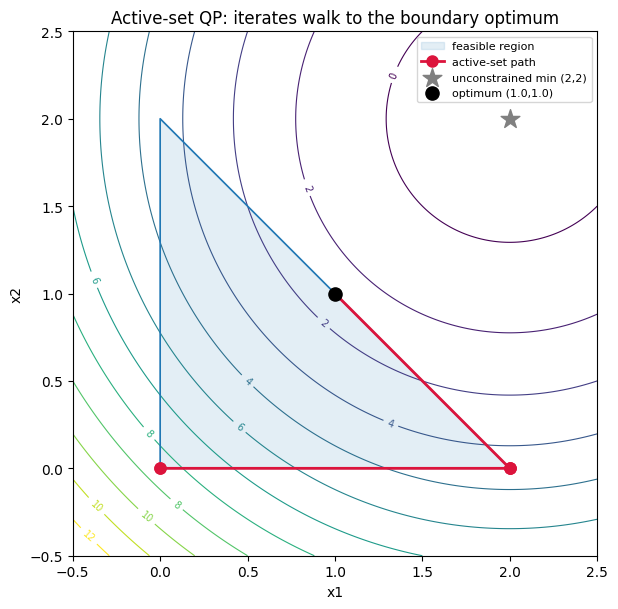

In [5]:
# ----- 실현가능 영역 + 등고선 + iterate 경로 -----
xx = np.linspace(-0.5, 2.5, 400); yy = np.linspace(-0.5, 2.5, 400)
XX, YY = np.meshgrid(xx, yy)
ZZ = (XX-2)**2 + (YY-2)**2
fig, ax = plt.subplots(figsize=(7, 6.2))
cs = ax.contour(XX, YY, ZZ, levels=np.arange(0.5, 12, 1.0), cmap='viridis', linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=7, fmt='%.0f')
# feasible triangle (0,0),(2,0),(0,2)
tri = np.array([[0,0],[2,0],[0,2],[0,0]])
ax.fill(tri[:,0], tri[:,1], alpha=0.12, color='tab:blue', label='feasible region')
ax.plot(tri[:,0], tri[:,1], color='tab:blue', lw=1.2)
path = np.array([h_[2] for h_ in hist] + [x_as])
ax.plot(path[:,0], path[:,1], 'o-', color='crimson', lw=2, ms=8, label='active-set path')
ax.scatter(2, 2, marker='*', s=200, color='gray', zorder=5, label='unconstrained min (2,2)')
ax.scatter(*x_as, color='black', s=90, zorder=6, label=f'optimum ({x_as[0]:.1f},{x_as[1]:.1f})')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_aspect('equal')
ax.set_title('Active-set QP: iterates walk to the boundary optimum')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **경계로의 이동**: 무제약 최소점 $(2,2)$ 는 실현불가하므로, 활성집합법은 실현가능 삼각형 위를 걸어 제약 $x+y=2$ 에 닿는 점 $(1,1)$ 에서 멈춘다. 이는 $(2,2)$ 를 직선 $x+y=2$ 에 **정사영**한 점과 정확히 같다(목적이 등방성 원이므로).
2. **작업집합의 진화**: 출발점 $(0,0)$ 에서 $\{x\ge0,\,y\ge0\}$ 이 활성이지만, 그 점에서 승수가 음수(목적을 더 낮출 여지)라 제약을 하나 제거하고 이동하다 $x+y\le2$ 가 blocking되어 추가된다. 표의 `working_set` 열이 이 추가/제거 과정을 보여준다.
3. **상보여유성**: 최종해에서 활성인 $x+y\le2$ 의 승수만 양수($\mu=2$), 비활성인 $x\ge0,\,y\ge0$ 의 승수는 0 — KKT 조건이 정확히 충족된다.
4. **scipy 검증**: SLSQP 해와 $10^{-8}$ 이하로 일치. 활성집합법은 **유한 단계**(잘못된 추정을 cycling 없이 교정)에 정확해에 도달한다.
5. **Day48 내부점법과의 대비**: 같은 문제를 Day48 CE2의 로그장벽 내부점법은 **내부에서** $(1,1)$ 로 *접근*했다. 활성집합법은 **경계 위를 걸어** 정확히 도달한다 — 작은/중간 규모 QP에서 정확하고 빠르다.

> **결론**: 활성집합법은 "활성 제약 추정 → 등식 QP 풀이 → blocking 추가 / 음수승수 제거"를 반복해, 부등식 QP를 유한 단계의 등식 QP 연쇄로 정확히 푼다.

**다음 문제로의 연결**: 승수 $\boldsymbol\mu$ 는 단순한 부산물이 아니라 **그림자가격**이다. Problem 3은 쌍대성과 민감도 분석으로 이 의미를 정량화한다.